In [ ]:
from IPython.display import Image
Image(url="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRb-iN02HWhBI_zxtYTfDxdkM96b9WuSdZtulck9BfkU0ZPn2JHHUmOoTkMgvO8lp1gRx4&usqp=CAU")

In [ ]:
!pip install statsmodels

In [ ]:
!pip install wquantiles

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import trim_mean
from statsmodels import robust
import wquantiles
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv('/content/titanic-train.csv')

##Diccionario de datos:
* Survided: 0=no sobrevivión, 1= sobrevivió
* Sibsp = # de hermanos / esposos que embarcaron
* Parch = # de padres / hijos que embarcaron
* Ticket: Numero del tiquete
* Embarked: Puerto de embaracción C=Chebourg, Q=Queenstwon, S=Southapton

In [ ]:
%matplotlib inline
sns.set()

1. Analizando la relación entre las caracteristicas (features) con la probabilidad de supervivencia-mortalidad del TITANIC

In [ ]:
def bar_char(feature):
    # Change 'survived' to 'Survived' to match the actual column name in the DataFrame
    survived=df[df["Survived"]==1][feature].value_counts()
    dead=df[df["Survived"]==0][feature].value_counts()
    test=pd.DataFrame([survived,dead])
    test.index=["sobrevivientes","fallecidos"]
    test.plot(kind="bar",stacked=True,figsize=(10,5))

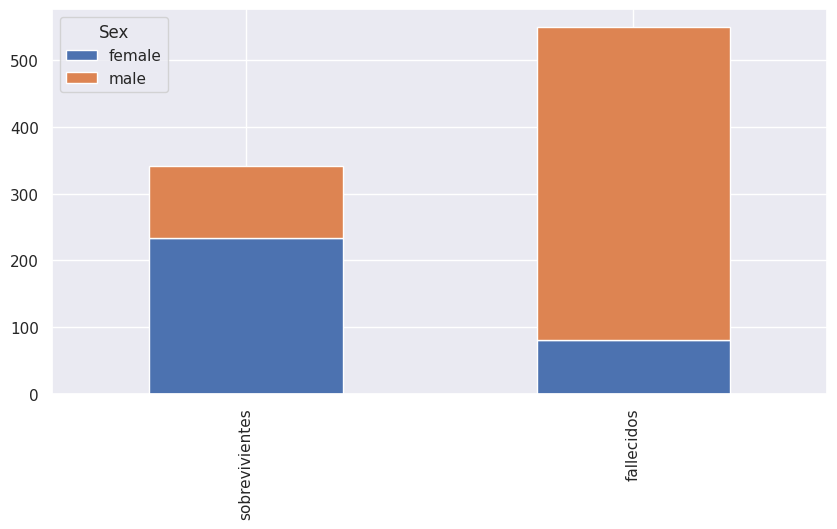

In [ ]:
bar_char("Sex")

De la figura, se concluye que **las mujeres** tuvieron mayor probablidiad de supervivencia que **los hombres**

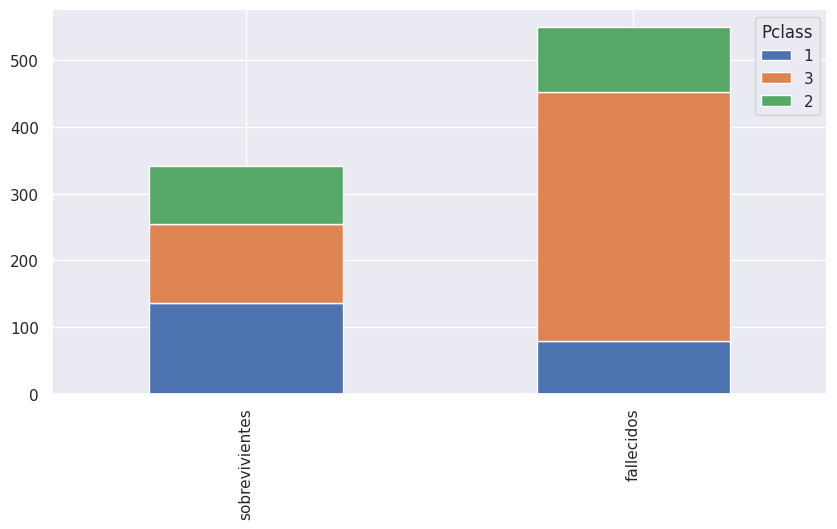

In [ ]:
bar_char("Pclass")

La gráfica identifica que la **clase 1** tuvo mayor chanse de supervivecia en comparación con las otras clases

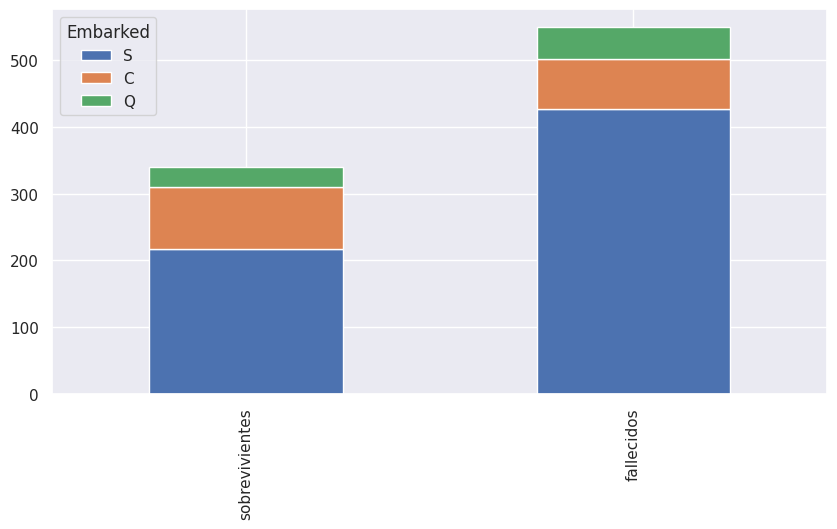

In [ ]:
bar_char("Embarked")

La gráfica confirma que:

* **Una persona que abordó desde C** tuvo una ligera probabilidad de sobrevivir.
* **Una persona que abordó desde Q o S** probablemente murió.

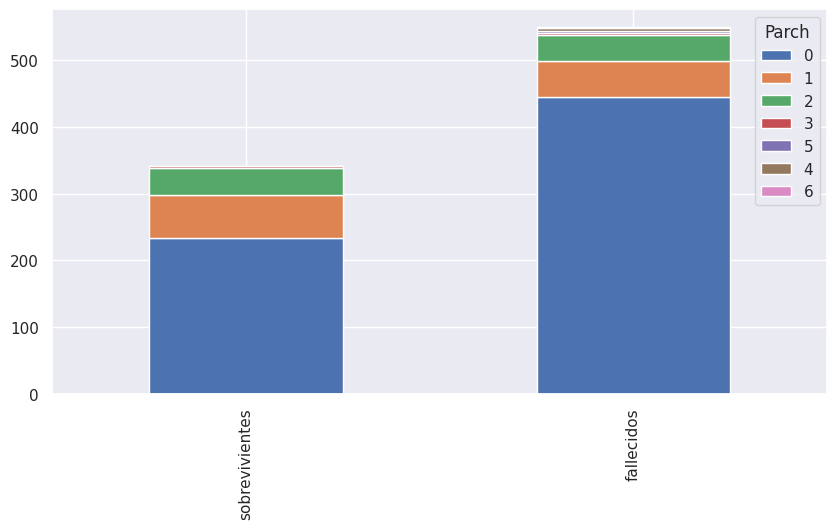

In [ ]:
bar_char("Parch")

De acuerdo al gráfico, los sobrevivientes tenían **al menos un hijo**

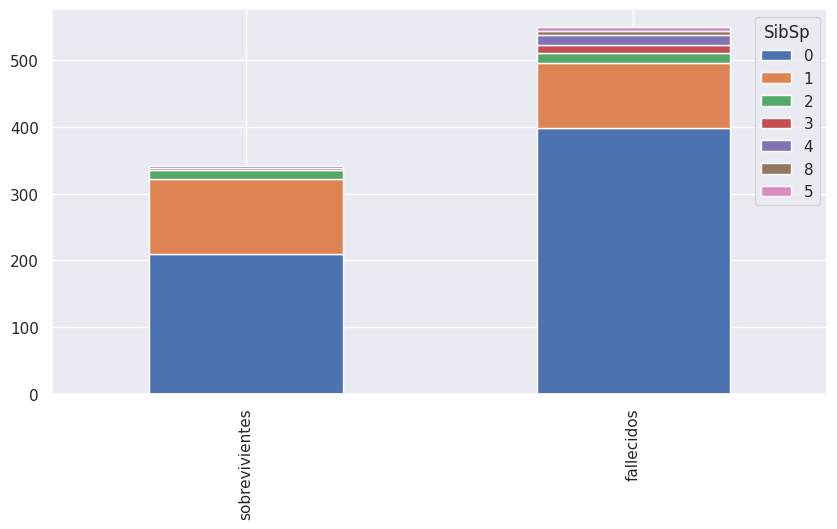

In [ ]:
bar_char("SibSp")

La gráfica señala que **una persona casada o con hermanos** tuvo más probabilidad de supervivencia que una persona **soltera.**

#Ingeniería de las caracteristicas
Es el proceso de usar dominio de conocimiento de los datos para crear nuevas caracteristicas (feature vectors) con el fin de logarg algoritmos de machine learnign funcionen correctamente.
Feature vectors son vectores n-dimensiones que representan un objeti, Muchos algoritmos en ML requieren una representación numérica de los objetos, ya que tales representaciones facilitan ek procesamiento y el análisis estadistico.

##¿Cómo se hundió el Titanic?
De acuerdo a lo conocido, por la proa del barco donde estaban las habitaciones de tercera clase

Conclusión, Pclass es la característica clave para el clasificador

In [ ]:
from IPython.display import Image
Image(url="https://fotografias.larazon.es/clipping/cmsimages01/2019/08/07/D501FC61-021E-4F05-BA33-DD4746405F80/98.jpg?crop=750,422,x46,y0&width=1900&height=1069&optimize=low&format=webply")

In [107]:
def extract_title(data):
  title=data["Name"].str.extract('([A-Za-z]+)\.',expand=True)
  return title

In [109]:
df["Title"]=extract_title(df)

In [110]:
df["Title"].value_counts()

,count
Title,
Mr,517
Miss,182
Mrs,125
Master,40
Dr,7
Rev,6
Col,2
Mlle,2
Major,2


##2.1 Creando un mapeo de los titulos
Reeemplazamos los titulos encontrados con los siguientes valores
* Mr: 0
* Miss: 1
* Mrs: 2
* Otros: 3

In [111]:
def replace_titles(data):
    title_mapping = {"Mr": 0, "Miss": 1, "Mrs":2}
    data["Title"] =data["Title"].map(title_mapping).fillna(3)
    return data

In [112]:
df=replace_titles(df)
df[["Name","Title"]].head()

,Name,Title
0,"Braund, Mr. Owen Harris",0.0
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",2.0
2,"Heikkinen, Miss. Laina",1.0
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",2.0
4,"Allen, Mr. William Henry",0.0


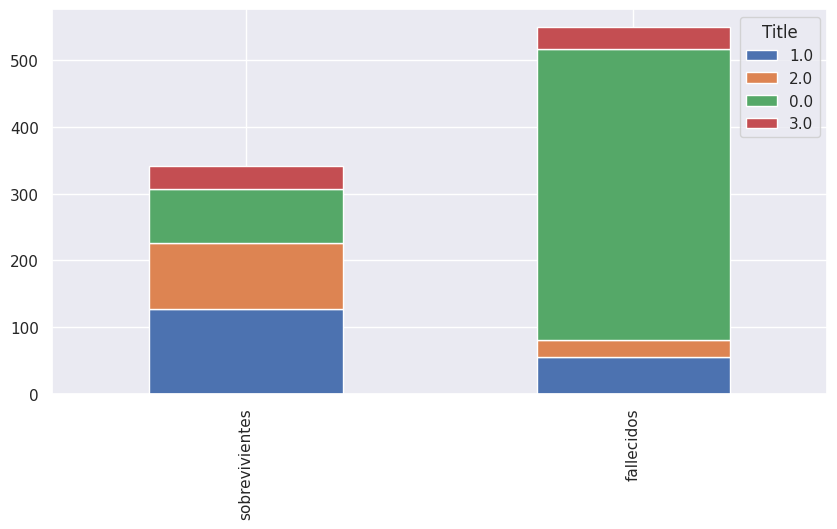

In [113]:
bar_char("Title")

Segun el grafico **las Mrs** sobrevivieron más en comparación que **las Miss** y estas dos sobrevivieron más que **los Mr**

##2.4 EDAD
###2.4.1 Rellenar los NaN en edades
Estrategia: Secalcula la media de los titulos y se reemplaza por las edades faltantes

In [ ]:
title_age_means=df.groupby("Title")["Age"].mean()
title_age_means

,Age
Title,
0.0,32.368090
1.0,21.773973
2.0,35.898148
3.0,20.430161


In [ ]:
df["Age"]=df.apply(lambda x: title_age_means[x["Title"]] if pd.isnull(x["Age"]) else x["Age"],axis=1)

In [ ]:
df[["Title","Age"]].head()

,Title,Age
0,0.0,22.0
1,2.0,38.0
2,1.0,26.0
3,2.0,35.0
4,0.0,35.0


In [ ]:
df[["Title","Age"]].sample(15)

,Title,Age
170,0.0,61.000000
14,1.0,14.000000
657,2.0,32.000000
842,1.0,30.000000
721,0.0,17.000000
216,1.0,27.000000
618,1.0,4.000000
96,0.0,71.000000
741,0.0,36.000000
479,1.0,2.000000


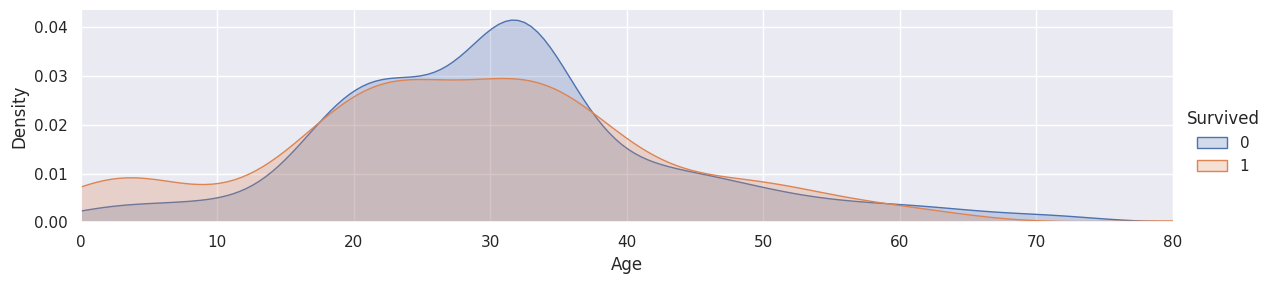

In [ ]:
facet=sns.FacetGrid(df,hue="Survived",aspect=4)
facet.map(sns.kdeplot,"Age",fill=True)
facet.set(xlim=(0,df["Age"].max()))
facet.add_legend()
plt.show()

(0.0, 20.0)

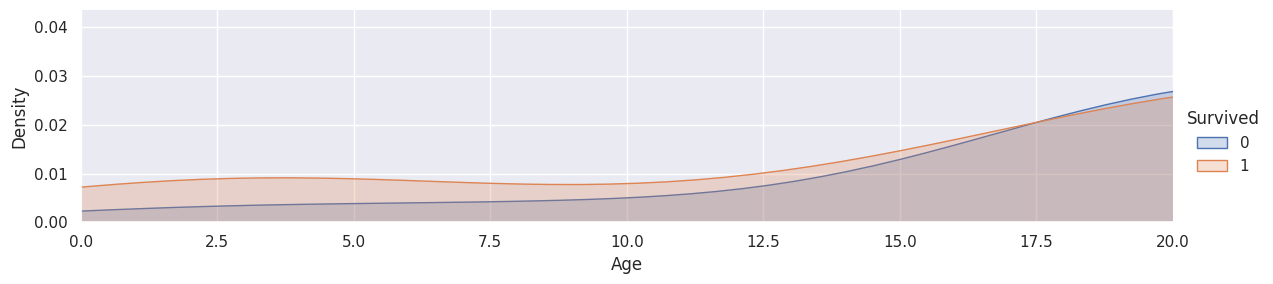

In [ ]:
facet=sns.FacetGrid(df,hue="Survived",aspect=4)
facet.map(sns.kdeplot,"Age",fill=True)
facet.set(xlim=(0,df["Age"].max()))
facet.add_legend()
plt.xlim(0,20)

(20.0, 30.0)

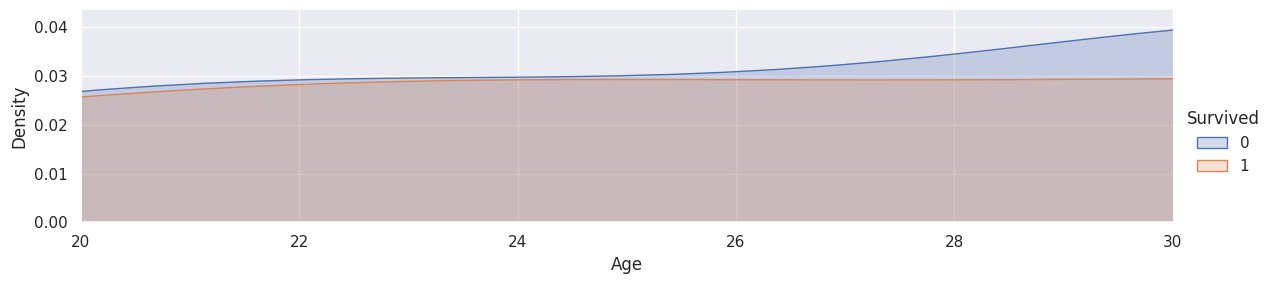

In [ ]:
facet=sns.FacetGrid(df,hue="Survived",aspect=4)
facet.map(sns.kdeplot,"Age",fill=True)
facet.set(xlim=(0,df["Age"].max()))
facet.add_legend()
plt.xlim(20,30)

(30.0, 40.0)

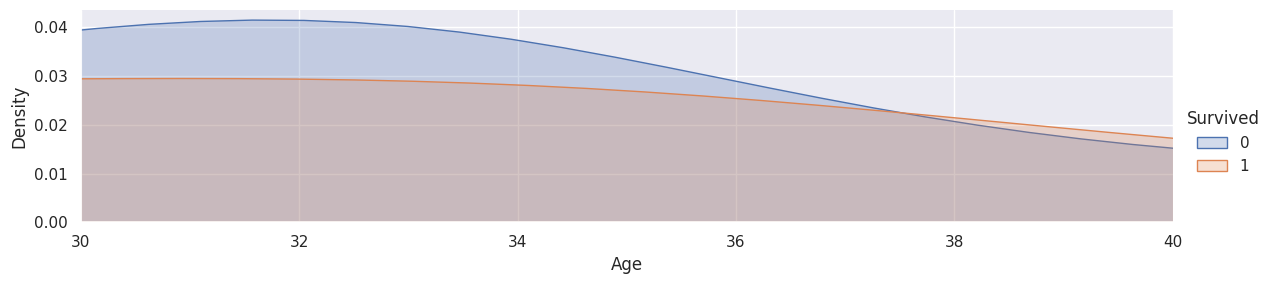

In [ ]:
facet=sns.FacetGrid(df,hue="Survived",aspect=4)
facet.map(sns.kdeplot,"Age",fill=True)
facet.set(xlim=(0,df["Age"].max()))
facet.add_legend()
plt.xlim(30,40)

(40.0, 60.0)

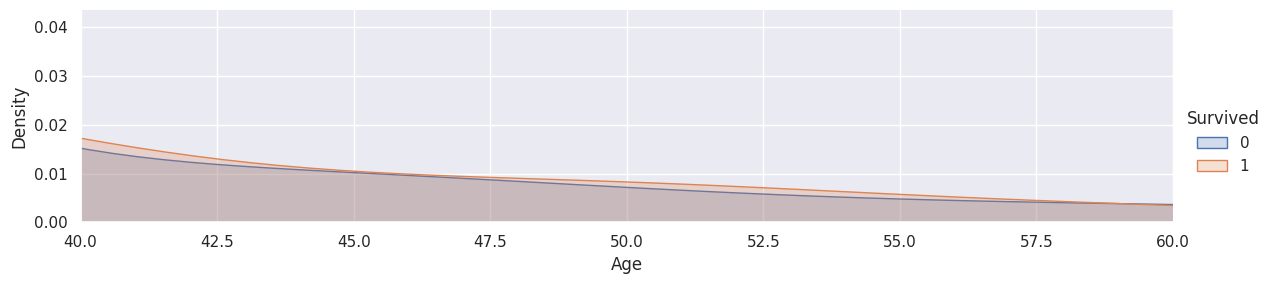

In [ ]:
facet=sns.FacetGrid(df,hue="Survived",aspect=4)
facet.map(sns.kdeplot,"Age",fill=True)
facet.set(xlim=(0,df["Age"].max()))
facet.add_legend()
plt.xlim(40,60)

(60.0, 80.0)

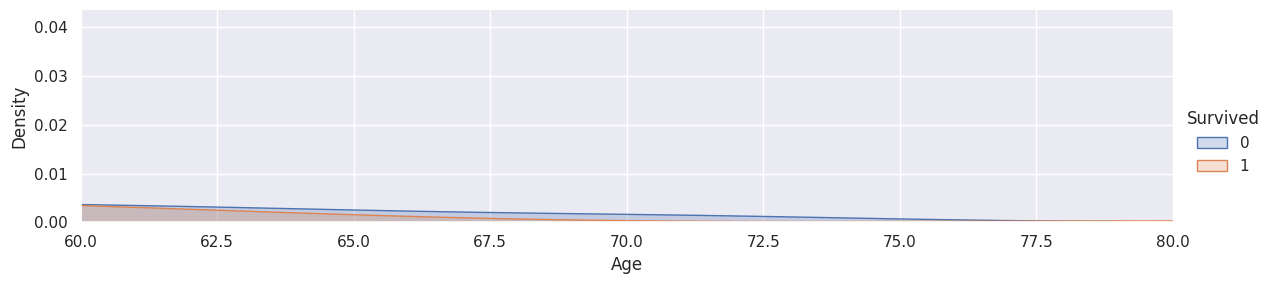

In [ ]:
facet=sns.FacetGrid(df,hue="Survived",aspect=4)
facet.map(sns.kdeplot,"Age",fill=True)
facet.set(xlim=(0,df["Age"].max()))
facet.add_legend()
plt.xlim(60)

##2.4.2 Binning
Es convertir una variable numérica a categórica, en este caso la edad.
* Niño: 0
* Joven: 1
* Adulto: 2
* Edad madura: 3
* Edad avanzada: 4

In [ ]:
df["Age_Category"]=pd.cut(df["Age"],bins=[0,16,26,36,62,float("inf")],labels=[0,1,2,3,4],right=False)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Age_Category
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0.0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2.0,3
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1.0,2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2.0,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0.0,2


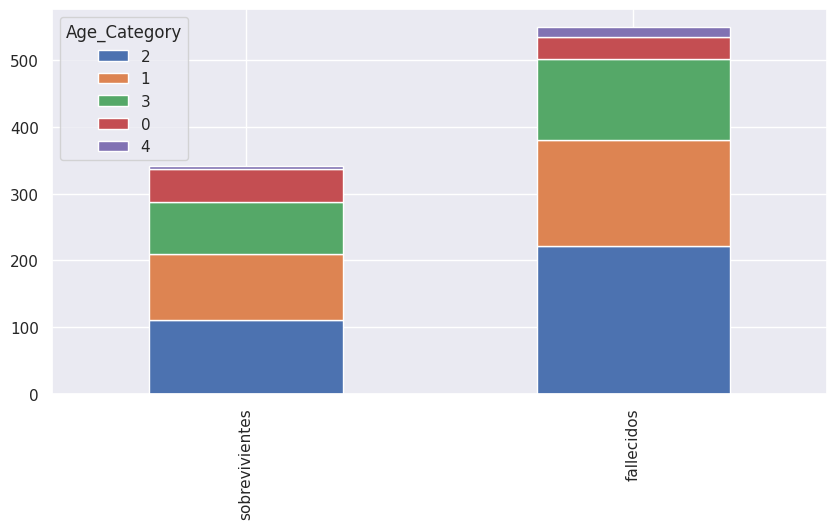

In [ ]:
bar_char("Age_Category")